Semantic visualization of Russian novel titles
===========================================

Loads processed titles of Russian novels (1763–1917), loads precomputed SBERT embeddings, projects them to 2D with UMAP, and visualizes the semantic space, highlighting all canonical authors and N random non‑canonical titles

In [13]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import hsv_to_rgb
import umap
from sklearn.metrics.pairwise import cosine_similarity
from adjustText import adjust_text
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

In [14]:
data = pd.read_csv('data/novels_titles_processed.csv')
data = data[data['year_begin'] != '19??']
data['year_begin'] = data['year_begin'].astype('int64')
data = data[data['year_begin'] <= 1917]
with open('data/sberbank-ai-sbert_large_nlu_ru_mp.pickle', 'rb') as f:
    title_to_embedding = pickle.load(f)
valid_titles = [t for t in data['title'].tolist() if t in title_to_embedding]
embeddings = np.array([title_to_embedding[t] for t in valid_titles])

In [15]:
coords_2d = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42).fit_transform(embeddings)
title_to_year = dict(zip(data['title'], data['year_begin']))
canonical_titles = set(data[data['canon_status'] == 1]['title'].tolist())

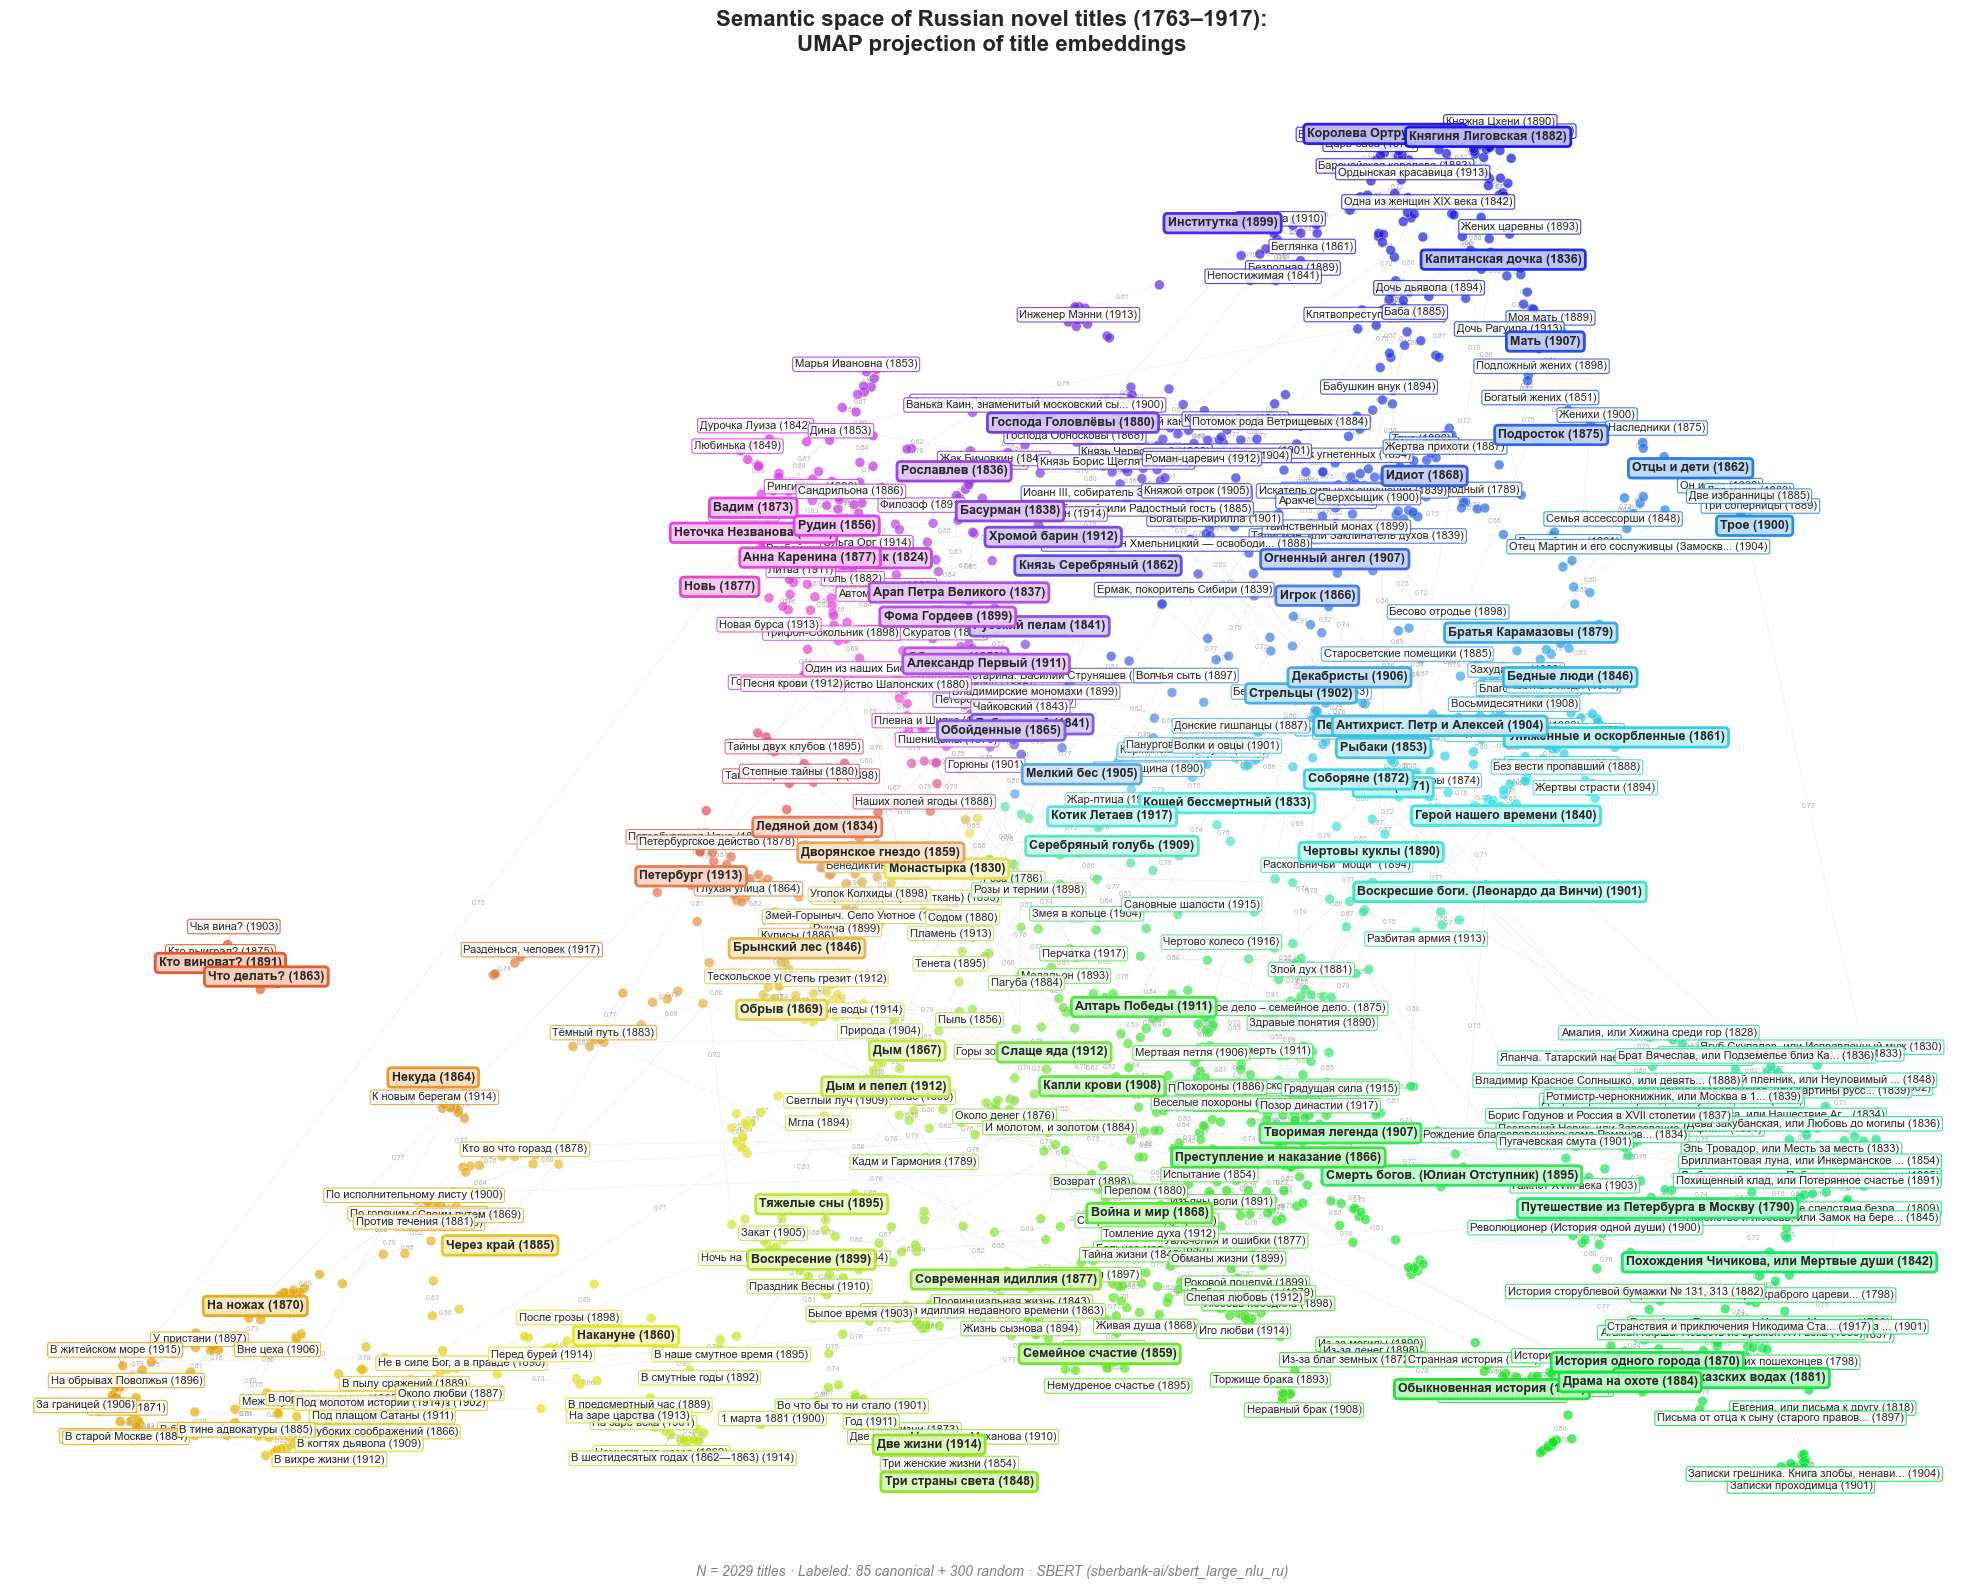

In [18]:
x_norm = (coords_2d[:, 0] - coords_2d[:, 0].min()) / (coords_2d[:, 0].max() - coords_2d[:, 0].min())
y_norm = (coords_2d[:, 1] - coords_2d[:, 1].min()) / (coords_2d[:, 1].max() - coords_2d[:, 1].min())
dx, dy = x_norm - 0.5, y_norm - 0.5
hue = (np.arctan2(dy, dx) + np.pi) / (2 * np.pi)
saturation = 0.6 + 0.4 * np.sqrt(dx**2 + dy**2) / np.sqrt(dx**2 + dy**2).max()
rgb_colors = np.array([hsv_to_rgb(c) for c in np.column_stack([hue, saturation, np.full_like(hue, 0.9)])])
sim = cosine_similarity(embeddings)
np.fill_diagonal(sim, 0)
nn = np.argmax(sim, axis=1)
drawn = set()
fig, ax = plt.subplots(figsize=(20, 16))
for i in range(len(valid_titles)):
    j = nn[i]
    p = tuple(sorted([i, j]))
    if p in drawn:
        continue
    drawn.add(p)
    ax.plot([coords_2d[i, 0], coords_2d[j, 0]], [coords_2d[i, 1], coords_2d[j, 1]], color='lightgray', lw=0.5, alpha=0.4, zorder=1)
    mx, my = (coords_2d[i, 0] + coords_2d[j, 0])/2, (coords_2d[i, 1] + coords_2d[j, 1])/2
    ax.text(mx, my, f'{sim[i,j]:.2f}', fontsize=5, color='gray', alpha=0.6, ha='center', va='center', zorder=2)
ax.scatter(coords_2d[:, 0], coords_2d[:, 1], c=rgb_colors, s=50, alpha=0.7, edgecolors='white', linewidth=0.3, zorder=3)
np.random.seed(42)
canon_idx = [i for i, t in enumerate(valid_titles) if t in canonical_titles]
non_canon_idx = [i for i, t in enumerate(valid_titles) if t not in canonical_titles]
rand_300 = np.random.choice(non_canon_idx, size=min(300, len(non_canon_idx)), replace=False)
to_label = set(canon_idx) | set(rand_300)
texts, seen = [], set()
for idx in to_label:
    t = valid_titles[idx]
    if t in seen:
        continue
    seen.add(t)
    lab = (t[:37] + '...' if len(t) > 40 else t) + (f' ({title_to_year[t]})' if title_to_year.get(t) else '')
    fc = tuple(0.3*c+0.7 for c in rgb_colors[idx]) if t in canonical_titles else 'white'
    fw = 'bold' if t in canonical_titles else 'normal'
    fs = 9 if t in canonical_titles else 8
    if t in canonical_titles:
        bbox = dict(boxstyle='round,pad=0.3', facecolor=tuple(0.3*c+0.7 for c in rgb_colors[idx]), alpha=0.95, edgecolor=rgb_colors[idx], linewidth=2)
        z = 5
    else:
        bbox = dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.85, edgecolor=rgb_colors[idx], linewidth=0.8)
        z = 4
    texts.append(ax.text(coords_2d[idx, 0], coords_2d[idx, 1], lab, fontsize=fs, fontweight=fw, ha='center', va='center', bbox=bbox, zorder=z))
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5, lw=0.5, shrinkA=15, shrinkB=15), expand_points=(1.5, 1.5), expand_text=(1.2, 1.2), force_text=(0.8, 0.8), force_points=(0.5, 0.5))
ax.set_title('Semantic space of Russian novel titles (1763–1917):\nUMAP projection of title embeddings', fontsize=16, fontweight='bold', linespacing=1.3)
ax.set_xticks([])
ax.set_yticks([])
for s in ax.spines:
    ax.spines[s].set_visible(False)
ax.text(0.5, -0.02, f'N = {len(valid_titles)} titles · Labeled: {len(canon_idx)} canonical + {len(rand_300)} random · SBERT (sberbank-ai/sbert_large_nlu_ru)', transform=ax.transAxes, ha='center', fontsize=10, color='gray', style='italic')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/semantic_space_random300.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()